# Reward landscape


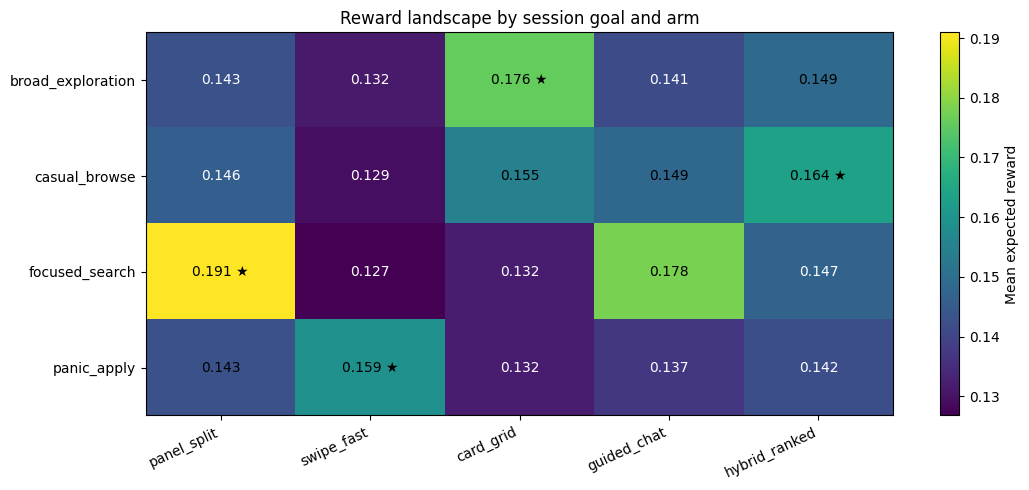

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path('..').resolve()
fig_dir = root / 'outputs' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
df = pd.read_parquet(root / 'data' / 'processed' / 'rounds_all_meta.parquet')
arms = ['panel_split','swipe_fast','card_grid','guided_chat','hybrid_ranked']
reward_cols = {a: f'exp_reward_{a}' for a in arms}
pivot = df.groupby('session_goal')[[reward_cols[a] for a in arms]].mean()
pivot = pivot.rename(columns={v:k for k,v in reward_cols.items()})
pivot = pivot.reindex(columns=arms)

plt.figure(figsize=(11, 5))
img = plt.imshow(pivot.values, aspect='auto')
for i in range(pivot.shape[0]):
    row = pivot.iloc[i].values
    best = int(np.argmax(row))
    for j, val in enumerate(row):
        txt = f'{val:.3f}' + (' ★' if j == best else '')
        plt.text(j, i, txt, ha='center', va='center', fontsize=10, color='white' if val < row.mean() else 'black')
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=25, ha='right')
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title('Reward landscape by session goal and arm')
plt.colorbar(label='Mean expected reward')
plt.tight_layout()
plt.savefig(fig_dir / 'reward_landscape_heatmap.png', dpi=220)
plt.show()
